# MovieLens 100K: User-based vs Item-based Collaborative Filtering

**Author:** Clara Nguyen  
**Last updated:** September 29, 2026

## Research question

Under a common, leakage-controlled evaluation protocol, how do user-based and item-based mean-centered KNN collaborative filtering compare on rating prediction error for MovieLens 100K?

This notebook is deliberately narrow. It evaluates explicit rating prediction with RMSE and MAE; it does **not** claim to evaluate the quality of a production top-N recommender.

## Design improvements over the initial analysis

- Downloads the official dataset at runtime instead of redistributing it.
- Uses the five predefined GroupLens train/test folds.
- Learns all statistics and similarities from each training fold only.
- Computes a regularized user/item-bias baseline on the same folds.
- Keeps the full catalog and reports KNN neighborhood coverage.
- Reports mean and standard deviation across folds rather than relying on one split.

## 1. Imports and reproducible data download

The MovieLens 100K license does not permit redistribution without separate permission. The cell below downloads the archive from GroupLens and verifies its MD5 checksum.

This cell works in Google Colab and in a local Jupyter environment.

In [1]:
from pathlib import Path
import hashlib
import urllib.request
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity

%matplotlib inline
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

DATA_URL = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
EXPECTED_MD5 = "0e33842e24a9c977be4e0107933c0723"
ZIP_PATH = Path("ml-100k.zip")
DATA_DIR = Path("ml-100k")

if not DATA_DIR.exists():
    if not ZIP_PATH.exists():
        print("Downloading MovieLens 100K from GroupLens...")
        urllib.request.urlretrieve(DATA_URL, ZIP_PATH)

    actual_md5 = hashlib.md5(ZIP_PATH.read_bytes()).hexdigest()
    if actual_md5 != EXPECTED_MD5:
        raise ValueError(f"Checksum mismatch: expected {EXPECTED_MD5}, got {actual_md5}")

    with zipfile.ZipFile(ZIP_PATH, "r") as archive:
        archive.extractall(".")

print("Data directory:", DATA_DIR)

Data directory: ml-100k


## 2. Load and validate the source tables

The original data are preserved. Quality checks are reported before any modeling transformation. GroupLens already removed users with fewer than 20 ratings, so no additional user or movie frequency filter is treated as "data cleaning."

In [2]:
RATING_COLUMNS = ["user_id", "movie_id", "rating", "timestamp"]
ratings = pd.read_csv(DATA_DIR / "u.data", sep="\t", names=RATING_COLUMNS)

GENRES = [
    "unknown", "Action", "Adventure", "Animation", "Children's", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
    "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western",
]
MOVIE_COLUMNS = [
    "movie_id", "title", "release_date", "video_release_date", "imdb_url", *GENRES
]
movies = pd.read_csv(
    DATA_DIR / "u.item",
    sep="|",
    names=MOVIE_COLUMNS,
    encoding="latin-1",
)

ratings["rated_at"] = pd.to_datetime(ratings["timestamp"], unit="s", utc=True)

quality_report = pd.Series({
    "ratings": len(ratings),
    "unique_users": ratings["user_id"].nunique(),
    "unique_movies_rated": ratings["movie_id"].nunique(),
    "missing_values": int(ratings.isna().sum().sum()),
    "duplicate_user_movie_pairs": int(ratings.duplicated(["user_id", "movie_id"]).sum()),
    "ratings_outside_1_to_5": int((~ratings["rating"].between(1, 5)).sum()),
    "movie_ids_missing_from_metadata": int((~ratings["movie_id"].isin(movies["movie_id"])).sum()),
})

display(quality_report.to_frame("value"))
display(ratings.head())

,value
ratings,100000
unique_users,943
unique_movies_rated,1682
missing_values,0
duplicate_user_movie_pairs,0
ratings_outside_1_to_5,0
movie_ids_missing_from_metadata,0


,user_id,movie_id,rating,timestamp,rated_at
0,196,242,3,881250949,1997-12-04 15:55:49+00:00
1,186,302,3,891717742,1998-04-04 19:22:22+00:00
2,22,377,1,878887116,1997-11-07 07:18:36+00:00
3,244,51,2,880606923,1997-11-27 05:02:03+00:00
4,166,346,1,886397596,1998-02-02 05:33:16+00:00


## 3. Exploratory analysis

The analysis focuses on quantities that affect neighborhood models: rating imbalance, user activity, item popularity, and matrix density.

,value
mean_rating,3.5299
median_rating,4.0000
matrix_density,0.0630
matrix_sparsity,0.9370
median_ratings_per_user,65.0000
median_ratings_per_movie,27.0000
first_rating_utc,1997-09-20 03:05:10+00:00
last_rating_utc,1998-04-22 23:10:38+00:00


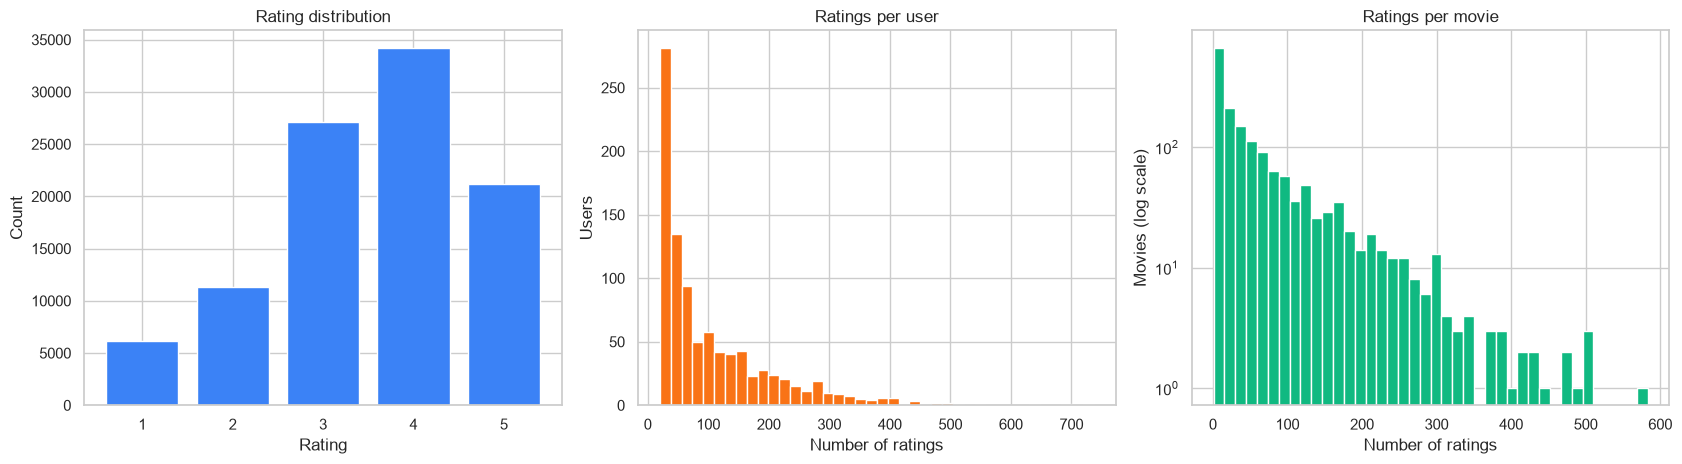

In [3]:
n_users = ratings["user_id"].nunique()
n_movies = ratings["movie_id"].nunique()
matrix_density = len(ratings) / (n_users * n_movies)

eda_summary = pd.Series({
    "mean_rating": ratings["rating"].mean(),
    "median_rating": ratings["rating"].median(),
    "matrix_density": matrix_density,
    "matrix_sparsity": 1 - matrix_density,
    "median_ratings_per_user": ratings.groupby("user_id").size().median(),
    "median_ratings_per_movie": ratings.groupby("movie_id").size().median(),
    "first_rating_utc": ratings["rated_at"].min(),
    "last_rating_utc": ratings["rated_at"].max(),
})
display(eda_summary.to_frame("value"))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

rating_counts = ratings["rating"].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color="#3b82f6")
axes[0].set(title="Rating distribution", xlabel="Rating", ylabel="Count", xticks=[1, 2, 3, 4, 5])

ratings.groupby("user_id").size().plot.hist(bins=40, color="#f97316", ax=axes[1])
axes[1].set(title="Ratings per user", xlabel="Number of ratings", ylabel="Users")

ratings.groupby("movie_id").size().plot.hist(bins=40, color="#10b981", logy=True, ax=axes[2])
axes[2].set(title="Ratings per movie", xlabel="Number of ratings", ylabel="Movies (log scale)")

plt.tight_layout()
plt.show()

## 4. Evaluation protocol

GroupLens supplies five predefined 80/20 splits (`u1`–`u5`). Test sets are disjoint. For every fold:

1. Fit a regularized bias model using only training ratings.
2. Construct a mean-centered user–item matrix from training data.
3. Compute user–user and item–item cosine similarity from training data.
4. Predict each held-out rating using up to 40 positive-similarity neighbors.
5. Fall back to the bias estimate when fewer than three eligible neighbors exist.

The bias model is a stronger and fairer baseline than a hard-coded global-mean RMSE.

In [4]:
def fit_bias_model(train, n_users, n_items, regularization=10.0, iterations=12):
    # Fit mu + user bias + item bias by alternating regularized updates.
    user_idx = train["user_id"].to_numpy(dtype=np.int32) - 1
    item_idx = train["movie_id"].to_numpy(dtype=np.int32) - 1
    values = train["rating"].to_numpy(dtype=np.float64)

    global_mean = float(values.mean())
    user_bias = np.zeros(n_users, dtype=np.float64)
    item_bias = np.zeros(n_items, dtype=np.float64)
    user_counts = np.bincount(user_idx, minlength=n_users)
    item_counts = np.bincount(item_idx, minlength=n_items)

    for _ in range(iterations):
        user_residual = values - global_mean - item_bias[item_idx]
        user_bias = np.bincount(user_idx, weights=user_residual, minlength=n_users) / (
            regularization + user_counts
        )

        item_residual = values - global_mean - user_bias[user_idx]
        item_bias = np.bincount(item_idx, weights=item_residual, minlength=n_items) / (
            regularization + item_counts
        )

    return global_mean, user_bias, item_bias


def make_centered_matrix(train, n_users, n_items):
    matrix = np.zeros((n_users, n_items), dtype=np.float32)
    user_idx = train["user_id"].to_numpy(dtype=np.int32) - 1
    item_idx = train["movie_id"].to_numpy(dtype=np.int32) - 1
    matrix[user_idx, item_idx] = train["rating"].to_numpy(dtype=np.float32)

    observed = matrix > 0
    counts = observed.sum(axis=1)
    user_means = np.divide(
        matrix.sum(axis=1),
        counts,
        out=np.zeros(n_users, dtype=np.float32),
        where=counts > 0,
    )
    centered = np.where(observed, matrix - user_means[:, None], 0.0).astype(np.float32)
    return matrix, observed, centered, user_means


def select_top_neighbors(similarities, values, k, min_k):
    eligible = similarities > 0
    similarities = similarities[eligible]
    values = values[eligible]

    if len(similarities) < min_k:
        return None
    if len(similarities) > k:
        top = np.argpartition(similarities, -k)[-k:]
        similarities = similarities[top]
        values = values[top]

    denominator = np.abs(similarities).sum()
    if denominator <= 0:
        return None
    return float(np.dot(similarities, values) / denominator)


def evaluate_fold(train, test, fold, n_users=943, n_items=1682, k=40, min_k=3):
    global_mean, user_bias, item_bias = fit_bias_model(train, n_users, n_items)
    matrix, observed, centered, user_means = make_centered_matrix(train, n_users, n_items)

    user_similarity = cosine_similarity(centered, dense_output=True).astype(np.float32)
    item_similarity = cosine_similarity(centered.T, dense_output=True).astype(np.float32)
    np.fill_diagonal(user_similarity, 0.0)
    np.fill_diagonal(item_similarity, 0.0)

    test_users = test["user_id"].to_numpy(dtype=np.int32) - 1
    test_items = test["movie_id"].to_numpy(dtype=np.int32) - 1
    actual = test["rating"].to_numpy(dtype=np.float64)

    baseline = np.clip(global_mean + user_bias[test_users] + item_bias[test_items], 1, 5)
    user_predictions = baseline.copy()
    item_predictions = baseline.copy()
    user_has_neighbors = np.zeros(len(test), dtype=bool)
    item_has_neighbors = np.zeros(len(test), dtype=bool)

    for row, (user, item) in enumerate(zip(test_users, test_items)):
        raters = np.flatnonzero(observed[:, item])
        user_adjustment = select_top_neighbors(
            user_similarity[user, raters], centered[raters, item], k, min_k
        )
        if user_adjustment is not None:
            user_predictions[row] = np.clip(user_means[user] + user_adjustment, 1, 5)
            user_has_neighbors[row] = True

        rated_items = np.flatnonzero(observed[user])
        item_adjustment = select_top_neighbors(
            item_similarity[item, rated_items], centered[user, rated_items], k, min_k
        )
        if item_adjustment is not None:
            item_predictions[row] = np.clip(user_means[user] + item_adjustment, 1, 5)
            item_has_neighbors[row] = True

    rows = []
    for model, predictions, coverage in [
        ("Bias baseline", baseline, np.ones(len(test), dtype=bool)),
        ("User KNN", user_predictions, user_has_neighbors),
        ("Item KNN", item_predictions, item_has_neighbors),
    ]:
        rows.append({
            "fold": fold,
            "model": model,
            "rmse": np.sqrt(mean_squared_error(actual, predictions)),
            "mae": mean_absolute_error(actual, predictions),
            "neighbor_coverage": coverage.mean(),
            "test_ratings": len(test),
        })

    return pd.DataFrame(rows)

## 5. Run the five official folds

The same code path and hyperparameters are used for all models and folds. Results are stored at the fold level so variation remains visible.

In [5]:
fold_results = []

for fold in range(1, 6):
    train = pd.read_csv(
        DATA_DIR / f"u{fold}.base",
        sep="\t",
        names=RATING_COLUMNS,
    )
    test = pd.read_csv(
        DATA_DIR / f"u{fold}.test",
        sep="\t",
        names=RATING_COLUMNS,
    )

    result = evaluate_fold(train, test, fold=fold)
    fold_results.append(result)
    print(f"Completed fold {fold}")

fold_results = pd.concat(fold_results, ignore_index=True)
display(fold_results)

Completed fold 1


Completed fold 2


Completed fold 3


Completed fold 4


Completed fold 5


,fold,model,rmse,mae,neighbor_coverage,test_ratings
0,1,Bias baseline,0.9591,0.7599,1.0000,20000
1,1,User KNN,0.9479,0.7410,0.9881,20000
2,1,Item KNN,0.9511,0.7443,0.9963,20000
3,2,Bias baseline,0.9469,0.7479,1.0000,20000
4,2,User KNN,0.9359,0.7279,0.9889,20000
5,2,Item KNN,0.9314,0.7268,0.9979,20000
6,3,Bias baseline,0.9399,0.7433,1.0000,20000
7,3,User KNN,0.9341,0.7290,0.9892,20000
8,3,Item KNN,0.9269,0.7242,0.9978,20000
9,4,Bias baseline,0.9375,0.7429,1.0000,20000


## 6. Aggregate results

Mean performance answers the primary comparison. Standard deviation shows whether the result is stable across the five predefined folds. Because the training sets overlap, these fold results are not treated as five independent samples for a formal significance claim.

,model,mean_rmse,sd_rmse,mean_mae,sd_mae,mean_neighbor_coverage
0,Bias baseline,0.9448,0.0087,0.7484,0.0068,1.0000
1,User KNN,0.9361,0.0069,0.7312,0.0058,0.9895
2,Item KNN,0.9341,0.0099,0.7308,0.0083,0.9970


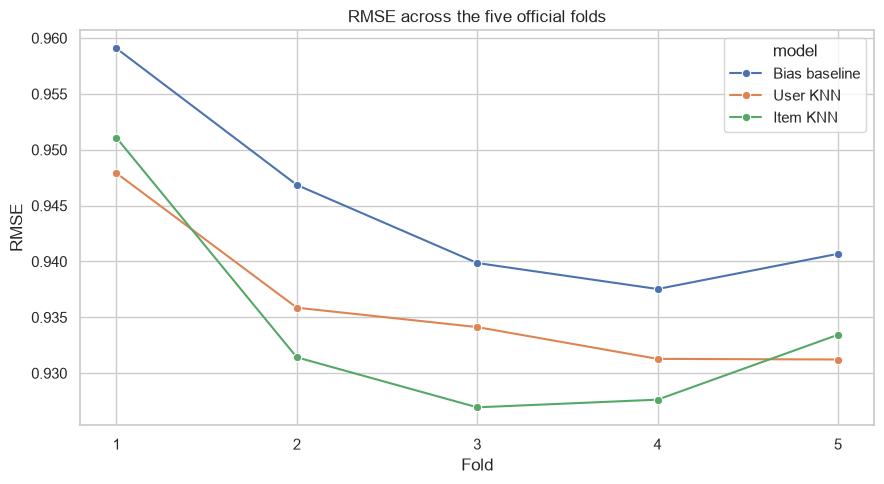

In [6]:
model_order = ["Bias baseline", "User KNN", "Item KNN"]

summary = (
    fold_results.groupby("model", as_index=False)
    .agg(
        mean_rmse=("rmse", "mean"),
        sd_rmse=("rmse", "std"),
        mean_mae=("mae", "mean"),
        sd_mae=("mae", "std"),
        mean_neighbor_coverage=("neighbor_coverage", "mean"),
    )
)
summary["model"] = pd.Categorical(summary["model"], categories=model_order, ordered=True)
summary = summary.sort_values("model").reset_index(drop=True)
display(summary)

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(
    data=fold_results,
    x="fold",
    y="rmse",
    hue="model",
    hue_order=model_order,
    marker="o",
    ax=ax,
)
ax.set(title="RMSE across the five official folds", xlabel="Fold", ylabel="RMSE", xticks=range(1, 6))
plt.tight_layout()
plt.show()

## 7. Interpretation

The following cell generates a deliberately cautious interpretation from the computed results. A lower mean RMSE is evidence for better rating prediction under this protocol, not a universal statement about recommender quality.

In [7]:
ranked = summary.sort_values("mean_rmse")
best = ranked.iloc[0]
user_row = summary.loc[summary["model"] == "User KNN"].iloc[0]
item_row = summary.loc[summary["model"] == "Item KNN"].iloc[0]
relative_difference = (item_row["mean_rmse"] - user_row["mean_rmse"]) / item_row["mean_rmse"] * 100

print(f"Lowest mean RMSE: {best['model']} ({best['mean_rmse']:.4f} ± {best['sd_rmse']:.4f})")
print(f"User KNN mean RMSE: {user_row['mean_rmse']:.4f}")
print(f"Item KNN mean RMSE: {item_row['mean_rmse']:.4f}")
print(f"Item-to-user relative RMSE difference: {relative_difference:+.2f}%")
print(f"User KNN neighborhood coverage: {user_row['mean_neighbor_coverage']:.1%}")
print(f"Item KNN neighborhood coverage: {item_row['mean_neighbor_coverage']:.1%}")

Lowest mean RMSE: Item KNN (0.9341 ± 0.0099)
User KNN mean RMSE: 0.9361
Item KNN mean RMSE: 0.9341
Item-to-user relative RMSE difference: -0.21%
User KNN neighborhood coverage: 99.0%
Item KNN neighborhood coverage: 99.7%


## 8. Conclusion and limitations

This experiment provides a reproducible comparison of two mean-centered neighborhood methods and a bias baseline. The result should be interpreted as conditional on MovieLens 100K, the official folds, cosine similarity, `k=40`, `min_k=3`, and the fallback policy.

The referenced study by Mohammadi Darani and Aghaie (2025) motivates interest in algorithm design, but this notebook does not directly test its claims about provider dynamics or long-run platform content. Such a test would require provider-side variables or a simulation design.

### Limitations

- Only one neighborhood size and one similarity metric are evaluated.
- RMSE and MAE assess rating prediction, not top-N ranking quality.
- Missing ratings are not missing at random; offline results can reflect exposure and selection bias.
- The data were collected in 1997–1998 and may not represent current platform behavior.
- The five predefined training folds overlap, so no formal significance claim is made from fold-level variation.

### Next steps

1. Tune `k`, `min_k`, similarity, and regularization using an inner validation split.
2. Add ranking evaluation such as Precision@K, Recall@K, and NDCG@K.
3. Compare against matrix factorization under the same folds.
4. Measure popularity bias, catalog coverage, and performance by user activity group.

## References

- Harper, F. M., & Konstan, J. A. (2015). *The MovieLens Datasets: History and Context*. ACM Transactions on Interactive Intelligent Systems, 5(4), Article 19. https://doi.org/10.1145/2827872
- Mohammadi Darani, M., & Aghaie, S. (2025). *Recommender systems impact on Platform's content and outcomes: the role of providers and algorithm designs*. Journal of Research in Interactive Marketing, 19(6), 917–935. https://doi.org/10.1108/JRIM-04-2024-0198